# Customer Churn Prediction - EDA and Model Training

**Dataset:** Telco Customer Churn (7043 records, 20 features)  
**Target:** Churn (Yes / No)  
**Pipeline:** EDA -> clean -> encode -> scale -> train multiple models -> compare -> save best

## 1. Imports and Configuration

In [26]:
import warnings
warnings.filterwarnings('ignore')

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)

# paths
ROOT       = Path('.')
DATA_PATH  = ROOT / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete')

Setup complete


## 2. Load Data

In [27]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


## 3. Exploratory Data Analysis

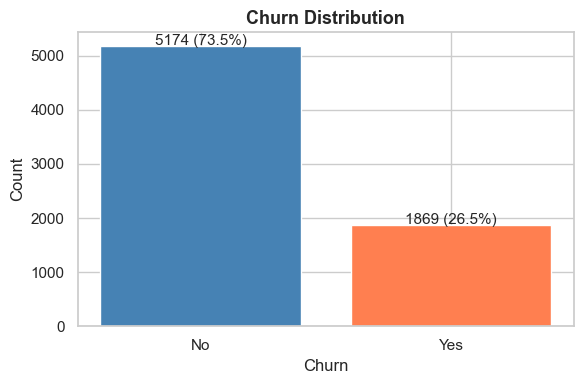

In [30]:
# target distribution
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df['Churn'].value_counts()
ax.bar(churn_counts.index, churn_counts.values, color=['steelblue', 'coral'])
ax.set_title('Churn Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

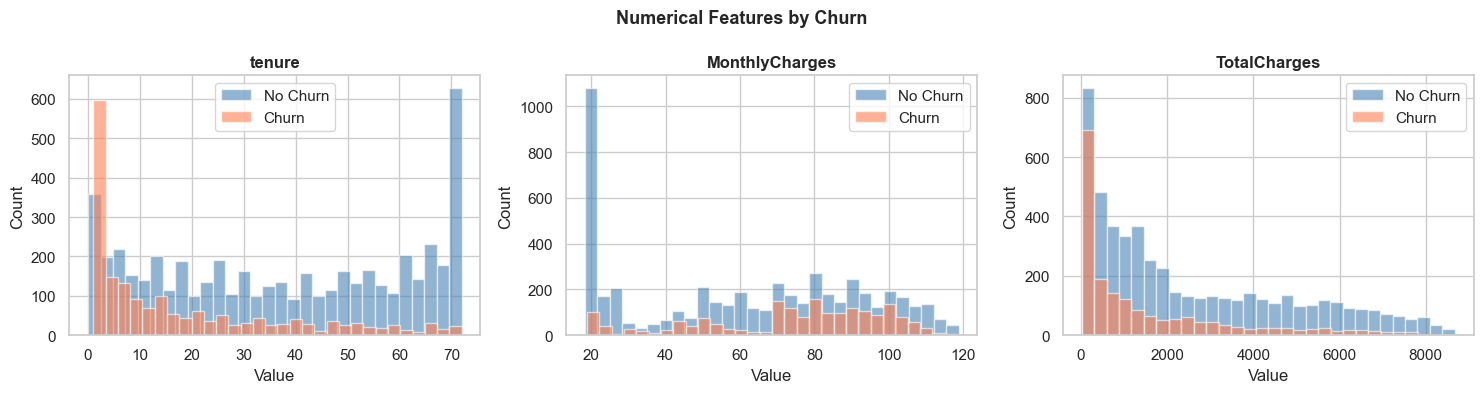

In [31]:
# numerical feature distributions by churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# fix TotalCharges first for plot
df_plot = df.copy()
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df_plot[df_plot['Churn'] == 'No'][col].dropna().hist(
        bins=30, ax=ax, alpha=0.6, color='steelblue', label='No Churn')
    df_plot[df_plot['Churn'] == 'Yes'][col].dropna().hist(
        bins=30, ax=ax, alpha=0.6, color='coral', label='Churn')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()
fig.suptitle('Numerical Features by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

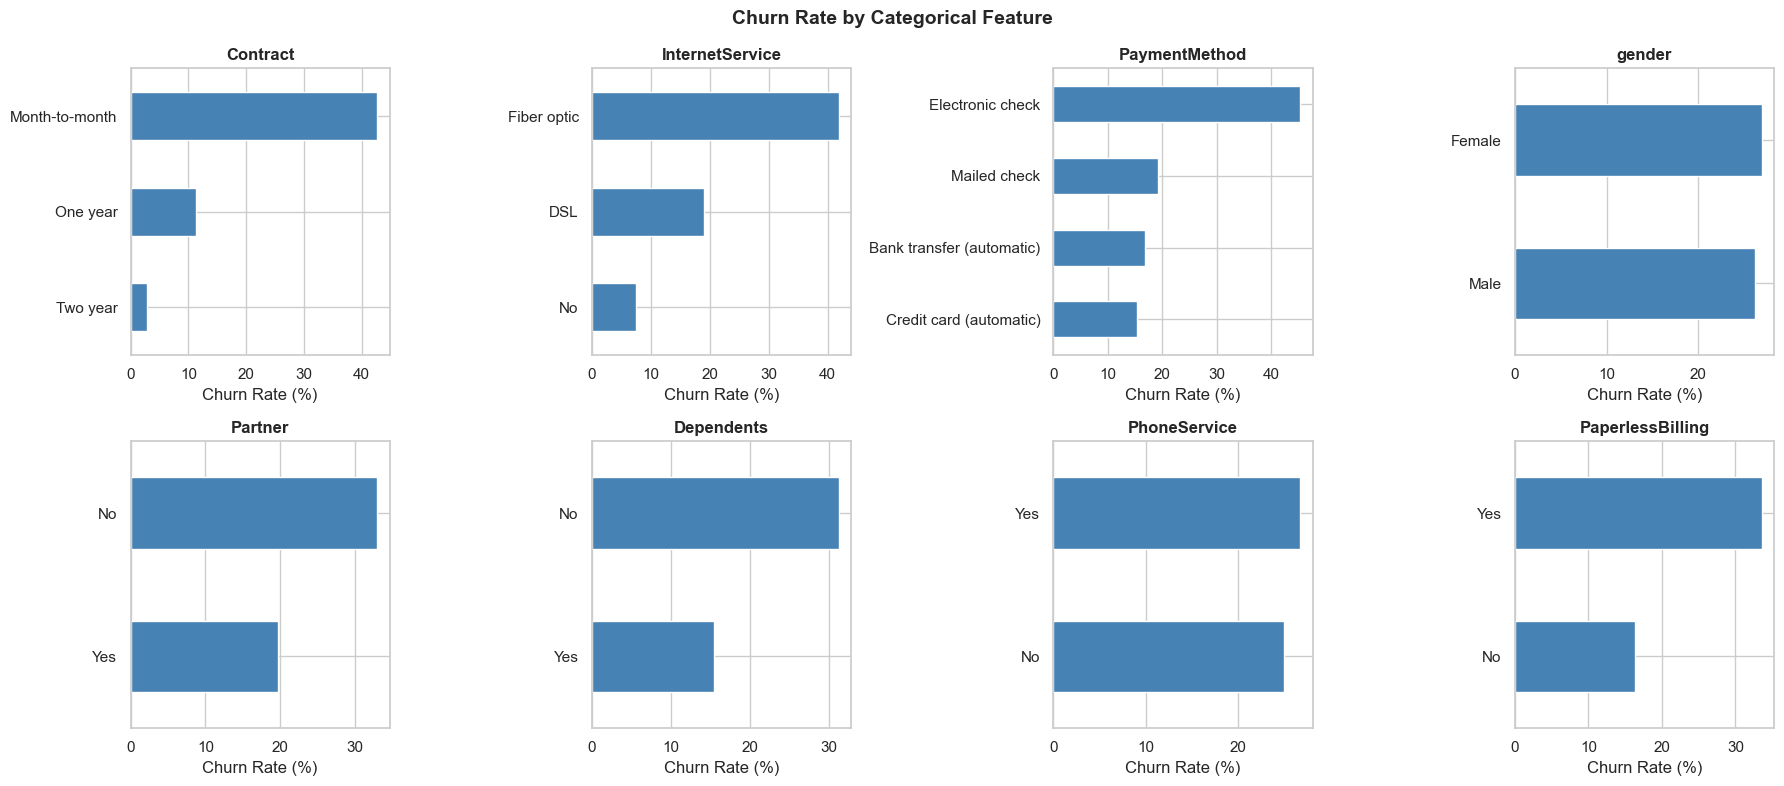

In [32]:
# categorical churn rates
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender',
            'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_ylabel('')
fig.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

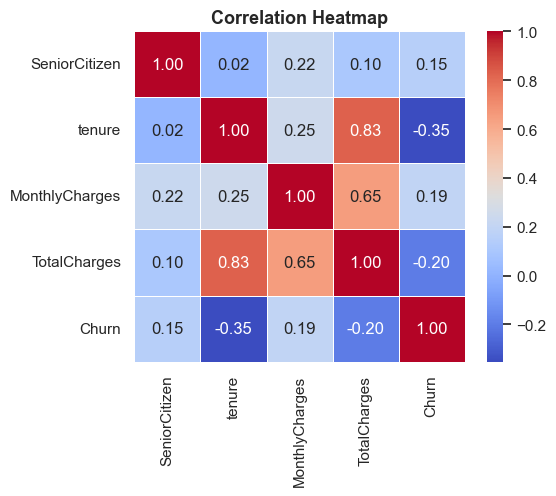

In [33]:
# correlation heatmap (numerical only)
df_corr = df_plot[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_corr['Churn'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [34]:
# 4.1 drop customerID, fix TotalCharges
df_clean = df.drop(columns=['customerID']).copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# fill missing TotalCharges with median
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)
print(f'Shape after cleaning: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')

Shape after cleaning: (7043, 20)
Missing values: 0


In [35]:
# 4.2 encode binary target
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)
print('Churn distribution after encoding:')
print(df_clean['Churn'].value_counts())

Churn distribution after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [36]:
# 4.3 encode categorical columns with LabelEncoder
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

print('Encoding done')
df_clean.head(3)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoding done


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


In [37]:
# 4.4 define features and target
FEATURES = [c for c in df_clean.columns if c != 'Churn']
X = df_clean[FEATURES].values
y = df_clean['Churn'].values

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'X shape: {X.shape}, y shape: {y.shape}')

Features (19): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
X shape: (7043, 19), y shape: (7043,)


In [38]:
# 4.5 train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%')

Train: (5634, 19)  |  Test: (1409, 19)
Train churn rate: 26.5%  |  Test churn rate: 26.5%


In [39]:
# 4.6 scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling done')

Scaling done


## 5. Model Training

In [40]:
# define all models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=7, metric='euclidean', n_jobs=-1
    ),
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Random Forest
  - Gradient Boosting
  - Logistic Regression
  - KNN


In [41]:
# train all models and collect results
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_sc, y_train)

    y_pred      = model.predict(X_test_sc)
    y_proba     = model.predict_proba(X_test_sc)[:, 1]
    test_acc    = accuracy_score(y_test, y_pred)
    test_f1     = f1_score(y_test, y_pred)
    test_roc    = roc_auc_score(y_test, y_proba)

    cv_scores   = cross_val_score(model, X_train_sc, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'test_acc': test_acc,
        'test_f1':  test_f1,
        'test_roc': test_roc,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
    }
    print(f'  Accuracy : {test_acc*100:.2f}%')
    print(f'  F1 Score : {test_f1:.4f}')
    print(f'  ROC AUC  : {test_roc:.4f}')
    print(f'  CV ROC   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print()

Training Random Forest...
  Accuracy : 78.78%
  F1 Score : 0.5490
  ROC AUC  : 0.8247
  CV ROC   : 0.8265 +/- 0.0107

Training Gradient Boosting...
  Accuracy : 80.13%
  F1 Score : 0.5783
  ROC AUC  : 0.8389
  CV ROC   : 0.8398 +/- 0.0096

Training Logistic Regression...
  Accuracy : 79.91%
  F1 Score : 0.5916
  ROC AUC  : 0.8403
  CV ROC   : 0.8446 +/- 0.0118

Training KNN...
  Accuracy : 75.23%
  F1 Score : 0.5173
  ROC AUC  : 0.7743
  CV ROC   : 0.7817 +/- 0.0054



## 6. Model Comparison

In [42]:
# summary table
summary = pd.DataFrame([
    {
        'Model':        name,
        'Accuracy':     f"{r['test_acc']*100:.2f}%",
        'F1 Score':     f"{r['test_f1']:.4f}",
        'ROC AUC':      f"{r['test_roc']:.4f}",
        'CV ROC Mean':  f"{r['cv_mean']:.4f}",
        'CV ROC Std':   f"{r['cv_std']:.4f}",
    }
    for name, r in results.items()
])
summary = summary.sort_values('ROC AUC', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model Accuracy F1 Score ROC AUC CV ROC Mean CV ROC Std
Logistic Regression   79.91%   0.5916  0.8403      0.8446     0.0118
  Gradient Boosting   80.13%   0.5783  0.8389      0.8398     0.0096
      Random Forest   78.78%   0.5490  0.8247      0.8265     0.0107
                KNN   75.23%   0.5173  0.7743      0.7817     0.0054


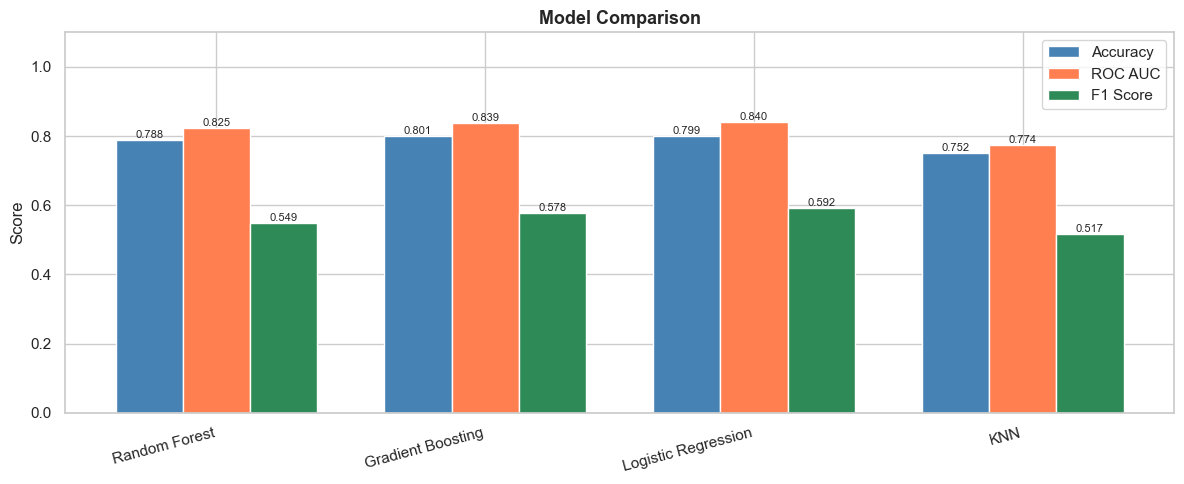

In [43]:
# comparison bar chart
names     = list(results.keys())
test_accs = [results[n]['test_acc'] for n in names]
test_rocs = [results[n]['test_roc'] for n in names]
test_f1s  = [results[n]['test_f1']  for n in names]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w,   test_accs, w, label='Accuracy',  color='steelblue')
b2 = ax.bar(x,       test_rocs, w, label='ROC AUC',   color='coral')
b3 = ax.bar(x + w,   test_f1s,  w, label='F1 Score',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

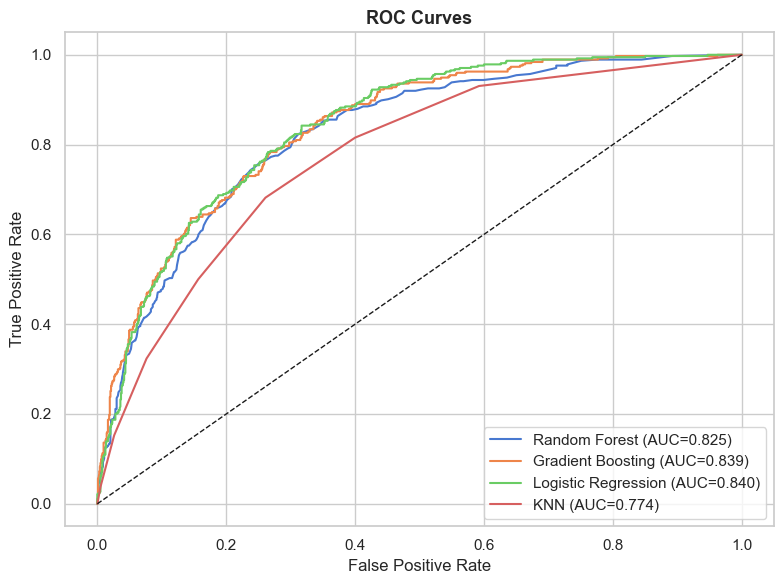

In [44]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['test_roc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [45]:
# select best model by ROC AUC
best_name   = max(results, key=lambda n: results[n]['test_roc'])
best_result = results[best_name]
best_model  = best_result['model']

print(f'Best model : {best_name}')
print(f'Accuracy   : {best_result["test_acc"]*100:.2f}%')
print(f'F1 Score   : {best_result["test_f1"]:.4f}')
print(f'ROC AUC    : {best_result["test_roc"]:.4f}')

Best model : Logistic Regression
Accuracy   : 79.91%
F1 Score   : 0.5916
ROC AUC    : 0.8403


## 7. Best Model Evaluation

In [46]:
print(f'Classification Report - {best_name}')
print(classification_report(y_test, best_result['y_pred'], target_names=['No Churn', 'Churn']))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



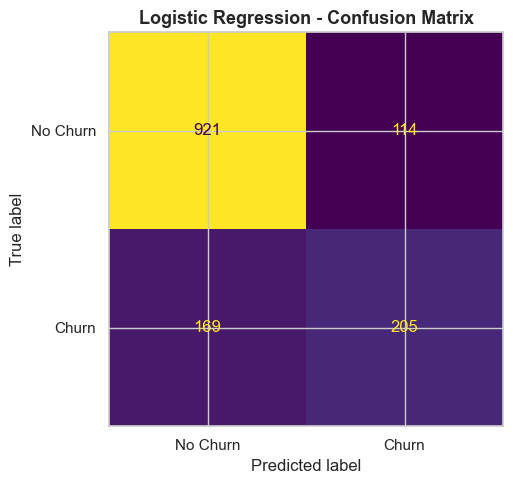

In [47]:
# confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_result['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False)
ax.set_title(f'{best_name} - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# feature importances (tree-based models only)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 7))
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{best_name} - Feature Importances', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} does not have feature_importances_. Skipping.')

Logistic Regression does not have feature_importances_. Skipping.


## 8. Save Best Model Artifacts

In [49]:
# save scaler
with open(MODELS_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('scaler.pkl saved')

# save label encoders
with open(MODELS_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print('label_encoders.pkl saved')

# save best model
with open(MODELS_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'best_model.pkl saved  ({best_name})')

# save metadata
metadata = {
    'features':      FEATURES,
    'best_model':    best_name,
    'test_accuracy': float(best_result['test_acc']),
    'test_f1':       float(best_result['test_f1']),
    'test_roc_auc':  float(best_result['test_roc']),
    'cv_roc_mean':   float(best_result['cv_mean']),
    'cv_roc_std':    float(best_result['cv_std']),
    'n_train':       int(X_train.shape[0]),
    'n_test':        int(X_test.shape[0]),
    'cat_cols':      cat_cols,
    'all_results': {
        name: {
            'test_acc': float(r['test_acc']),
            'test_f1':  float(r['test_f1']),
            'test_roc': float(r['test_roc']),
            'cv_mean':  float(r['cv_mean']),
            'cv_std':   float(r['cv_std']),
        }
        for name, r in results.items()
    }
}
with open(MODELS_DIR / 'metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print('metadata.pkl saved')

print(f'\nAll artifacts saved to: {MODELS_DIR.resolve()}')

scaler.pkl saved
label_encoders.pkl saved
best_model.pkl saved  (Logistic Regression)
metadata.pkl saved

All artifacts saved to: /home/prasanna/Desktop/Projects/Customer_churn/models


In [50]:
# sanity check: reload and predict
with open(MODELS_DIR / 'best_model.pkl', 'rb') as f:
    model_loaded = pickle.load(f)
with open(MODELS_DIR / 'scaler.pkl', 'rb') as f:
    scaler_loaded = pickle.load(f)
with open(MODELS_DIR / 'label_encoders.pkl', 'rb') as f:
    le_loaded = pickle.load(f)

# one sample row (raw values, first row of test set)
sample_sc = scaler_loaded.transform(X_test[:1])
pred      = model_loaded.predict(sample_sc)[0]
proba     = model_loaded.predict_proba(sample_sc)[0]

print(f'Prediction : {"Churn" if pred == 1 else "No Churn"}')
print(f'Churn prob : {proba[1]*100:.1f}%')
print('Sanity check passed')

Prediction : No Churn
Churn prob : 4.5%
Sanity check passed
